## Config paths/models

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import json
import os
import sys


PROJECT_ROOT = Path("/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/")
DATA_ROOT = Path("/scratch/vserrano/cbc_pe_data")

DATA_PROCESSED = DATA_ROOT / "processed"
RESULTS_DIR = DATA_ROOT / "results"
MODELS_DIR = DATA_ROOT / "models"
CHECKPOINTS_DIR = MODELS_DIR / "checkpoints"

dataset_id = "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"

checkpoint_id = (
    "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
    "_SimpleCNN"
    "_simple_emb64_mse"
    "_MSELoss"
    "_seed123"
)

pred_path = RESULTS_DIR / f"{checkpoint_id}_train_val_predictions_embeddings.npz"
history_path = RESULTS_DIR / f"{checkpoint_id}_history.npz"
checkpoint_path = CHECKPOINTS_DIR / f"{checkpoint_id}_checkpoint.pt"

assert pred_path.exists(), pred_path

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"PROJECT_ROOT does not exist: {PROJECT_ROOT}")

if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError(f"'src' directory not found inside PROJECT_ROOT: {PROJECT_ROOT / 'src'}")

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("cwd:", Path.cwd())
print("pred_path:", pred_path)
print("project_root exist:", PROJECT_ROOT.exists())
print("history_path exists:", history_path.exists())
print("checkpoint_path exists:", checkpoint_path.exists())

cwd: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe
pred_path: /scratch/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_simple_emb64_mse_MSELoss_seed123_train_val_predictions_embeddings.npz
project_root exist: True
history_path exists: True
checkpoint_path exists: True


## Load the preds(/embs)

In [2]:
from pathlib import Path
import numpy as np

LOCAL_DATA_ROOT = Path("/scratch/vserrano/cbc_pe_data")
DATA_PROCESSED = LOCAL_DATA_ROOT / "processed"

data = np.load(pred_path, allow_pickle=True)

pred_train = data["pred_train"]
y_train = data["y_train"]
emb_train = data["emb_train"]

pred_val = data["pred_val"]
y_val = data["y_val"]
emb_val = data["emb_val"]

y_mean = data["y_mean"]
y_std = data["y_std"]

train_idx = data["train_idx"]
val_idx = data["val_idx"]

label_names = data["label_names"].tolist()

# Ruta guardada durante entrenamiento, posiblemente de otra máquina
stored_dataset_path = Path(str(data["dataset_path"]))
stored_split_path = Path(str(data["split_path"]))
stored_label_stats_path = Path(str(data["label_stats_path"]))

print("stored_dataset_path:", stored_dataset_path)

# Reconstruir ruta local
dataset_path = DATA_PROCESSED / stored_dataset_path.name
split_path = DATA_PROCESSED / stored_split_path.name
label_stats_path = DATA_PROCESSED / stored_label_stats_path.name

print("local dataset_path:", dataset_path)
print("local split_path:", split_path)
print("local label_stats_path:", label_stats_path)

assert dataset_path.exists(), dataset_path

stored_dataset_path: /data/vserrano/cbc_pe_data/processed/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000.h5
local dataset_path: /scratch/vserrano/cbc_pe_data/processed/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000.h5
local split_path: /scratch/vserrano/cbc_pe_data/processed/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_splits_train80000_val20000_seed123.npz
local label_stats_path: /scratch/vserrano/cbc_pe_data/processed/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_label_stats_train_only_train80000_val20000_seed123.npz


## (Standarized) Metrics

In [3]:
from src.models.evaluate import regression_metrics, inverse_standardize

metrics_train_std = regression_metrics(
    y_true=y_train,
    y_pred=pred_train,
    label_names=label_names,
    split_name="train_std",
)

metrics_val_std = regression_metrics(
    y_true=y_val,
    y_pred=pred_val,
    label_names=label_names,
    split_name="val_std",
)

metrics_all_std = pd.concat(
    [metrics_train_std, metrics_val_std],
    ignore_index=True,
)

metrics_all_std

,split,label,MSE,RMSE,MAE,bias,median_abs_error,residual_std,R2
0,train_std,chirp_mass,0.089847,0.299745,0.220998,0.009582,0.163863,0.299590,0.910152
1,train_std,total_mass,0.069649,0.263911,0.202798,0.006136,0.161621,0.263840,0.930351
2,train_std,chi_eff,0.164700,0.405832,0.318109,-0.005389,0.262909,0.405795,0.835298
3,val_std,chirp_mass,0.140808,0.375244,0.268875,0.013185,0.191923,0.375013,0.857300
4,val_std,total_mass,0.112468,0.335363,0.249743,0.009372,0.189788,0.335232,0.885663
5,val_std,chi_eff,0.277973,0.527231,0.397517,0.007467,0.309465,0.527178,0.725214


In [4]:
print("train global MSE:", metrics_train_std["MSE"].mean())
print("val global MSE:", metrics_val_std["MSE"].mean())

train global MSE: 0.108065315
val global MSE: 0.17708302


## (Physical) Metrics

In [5]:
pred_train_phys = inverse_standardize(pred_train, y_mean, y_std)
y_train_phys = inverse_standardize(y_train, y_mean, y_std)

pred_val_phys = inverse_standardize(pred_val, y_mean, y_std)
y_val_phys = inverse_standardize(y_val, y_mean, y_std)

metrics_train_phys = regression_metrics(
    y_true=y_train_phys,
    y_pred=pred_train_phys,
    label_names=label_names,
    split_name="train_phys",
)

metrics_val_phys = regression_metrics(
    y_true=y_val_phys,
    y_pred=pred_val_phys,
    label_names=label_names,
    split_name="val_phys",
)

metrics_all_phys = pd.concat(
    [metrics_train_phys, metrics_val_phys],
    ignore_index=True,
)

metrics_all_phys

,split,label,MSE,RMSE,MAE,bias,median_abs_error,residual_std,R2
0,train_phys,chirp_mass,24.541489,4.953937,3.652527,0.158366,2.708200,4.951428,0.910154
1,train_phys,total_mass,84.042572,9.167474,7.044605,0.213129,5.614202,9.165018,0.930351
2,train_phys,chi_eff,0.031795,0.178312,0.139768,-0.002368,0.115516,0.178296,0.835301
3,val_phys,chirp_mass,38.462017,6.201776,4.443779,0.217914,3.171960,6.197942,0.857299
4,val_phys,total_mass,135.710419,11.649482,8.675298,0.325544,6.592640,11.644970,0.885663
5,val_phys,chi_eff,0.053663,0.231652,0.174658,0.003281,0.135971,0.231628,0.725214


## Training curve

['train_loss', 'val_loss']


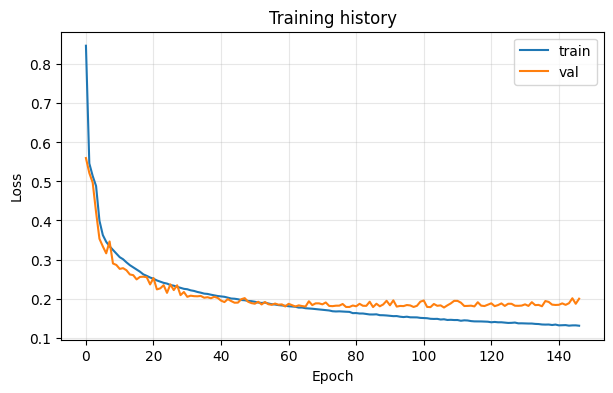

best val loss from history: 0.17708374972343444


In [6]:
if history_path.exists():
    history = np.load(history_path, allow_pickle=True)

    print(history.files)

    train_loss = history["train_loss"]
    val_loss = history["val_loss"]

    plt.figure(figsize=(7, 4))
    plt.plot(train_loss, label="train")
    plt.plot(val_loss, label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training history")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("best val loss from history:", np.min(val_loss))
else:
    print("No history file found:", history_path)

## Evaluation Plots

In [7]:
from src.models.plots import plot_pred_vs_true_density, plot_residuals, plot_mean_abs_error_vs_true_pred, plot_residual_vs_true_density, plot_abs_error_vs_quantity_density, plot_binned_error_vs_quantity

### Pred vs True

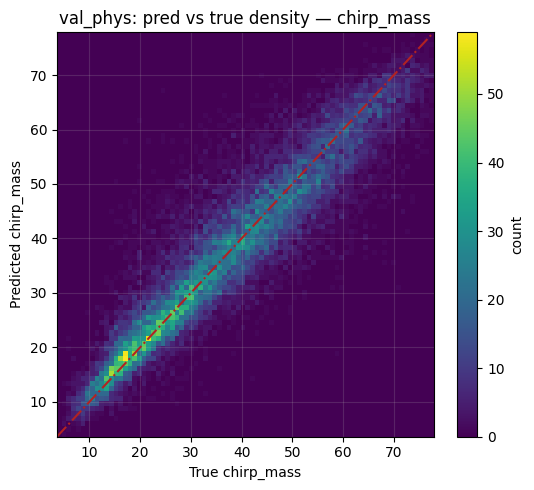

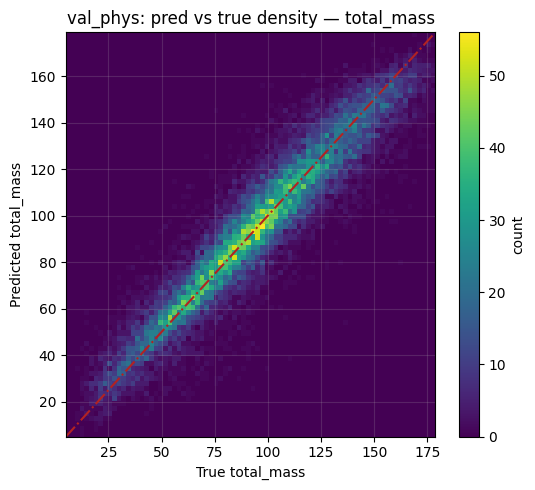

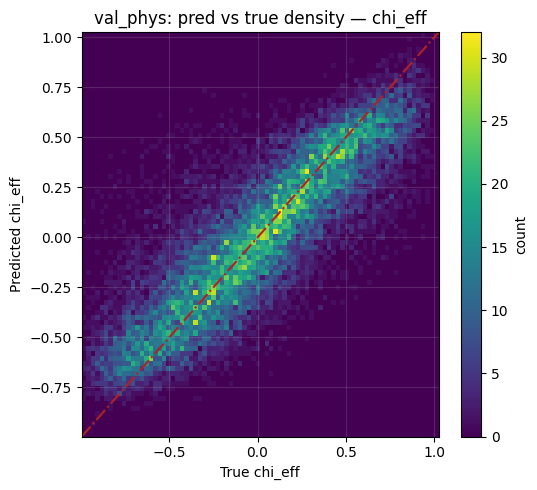

In [8]:
plot_pred_vs_true_density(
    y_true=y_val_phys,
    y_pred=pred_val_phys,
    label_names=label_names,
    split_name="val_phys",
)


### Residuals

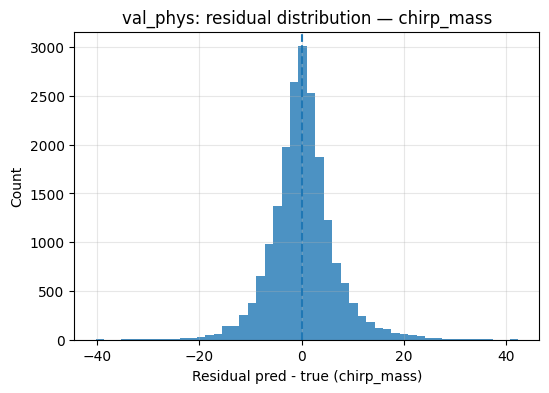

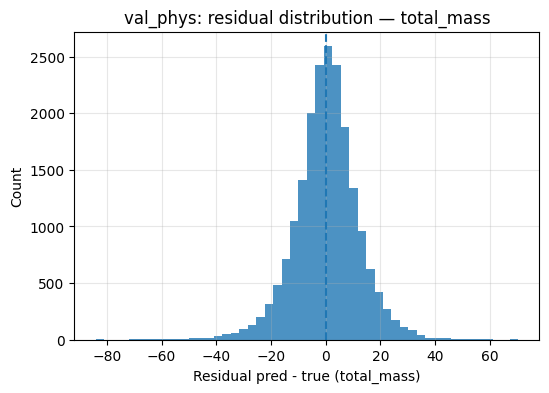

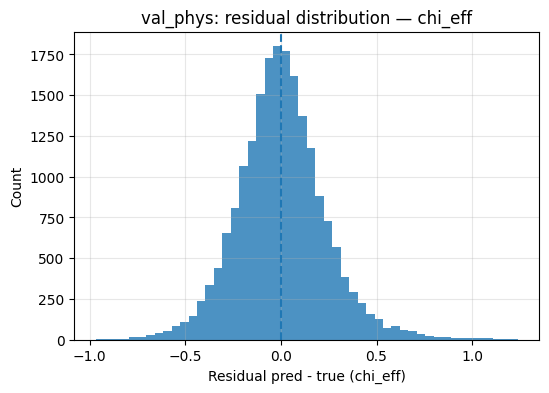

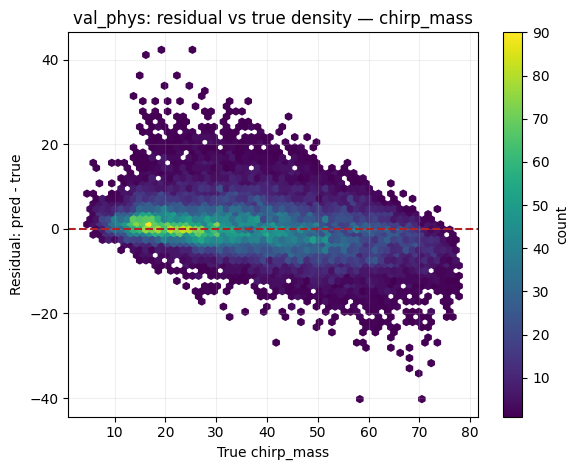

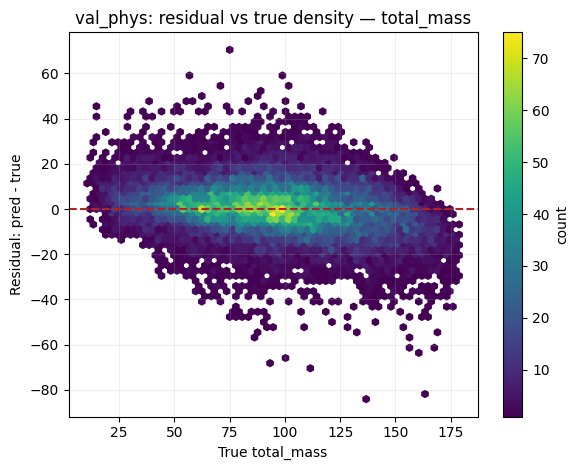

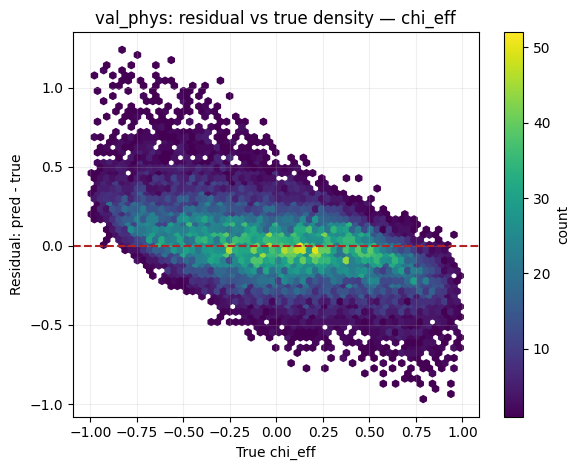

In [9]:
plot_residuals(y_val_phys, pred_val_phys, label_names, "val_phys")
plot_residual_vs_true_density(y_val_phys, pred_val_phys, label_names, "val_phys")

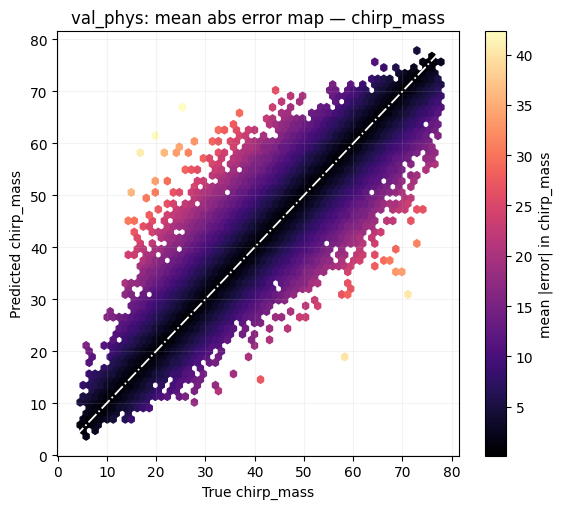

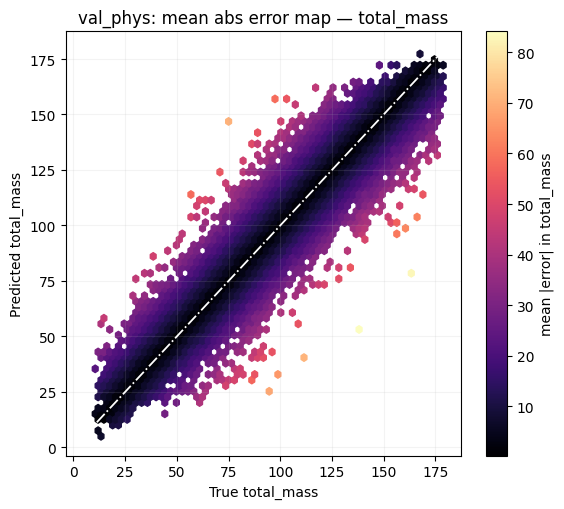

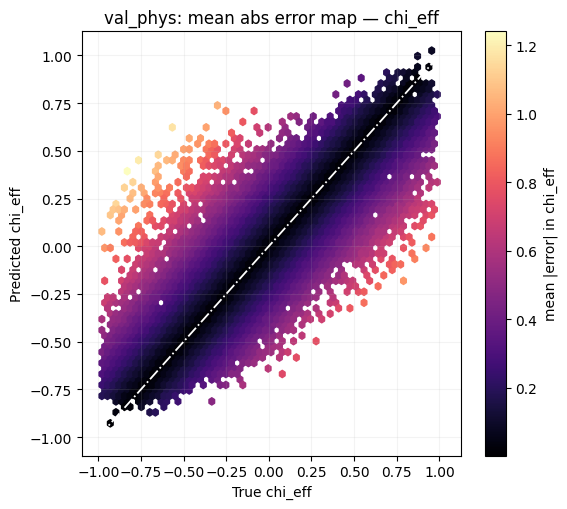

In [10]:
plot_mean_abs_error_vs_true_pred(
    y_true=y_val_phys,
    y_pred=pred_val_phys,
    label_names=label_names,
    split_name="val_phys",
)

### Error vs SNR

In [11]:
with h5py.File(dataset_path, "r") as f:
    print(list(f.keys()))
    print(list(f["snr"].keys()))

    snr_all = f["snr/network"][:]
    snr_train = snr_all[train_idx]
    snr_val = snr_all[val_idx]

print("snr_train:", snr_train.min(), snr_train.max())
print("snr_val:", snr_val.min(), snr_val.max())

['X', 'generation', 'parameters', 'snr', 'y']
['H1', 'L1', 'V1', 'network']
snr_train: 10.000435 24.999964
snr_val: 10.000044 24.999315


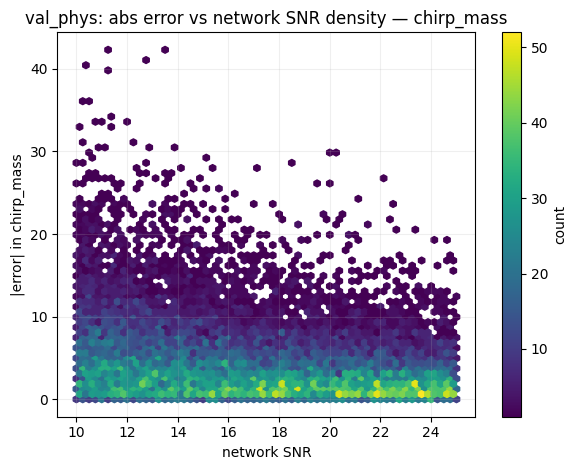

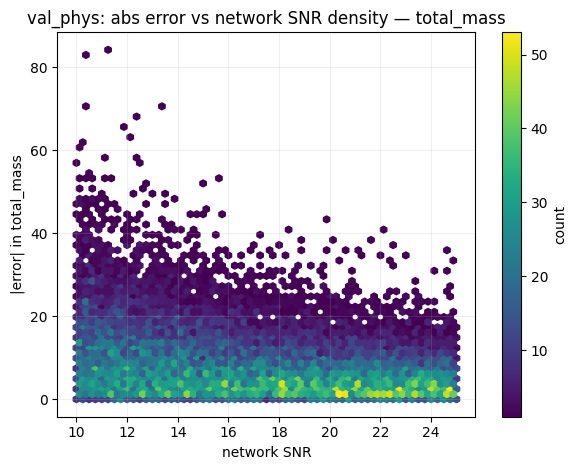

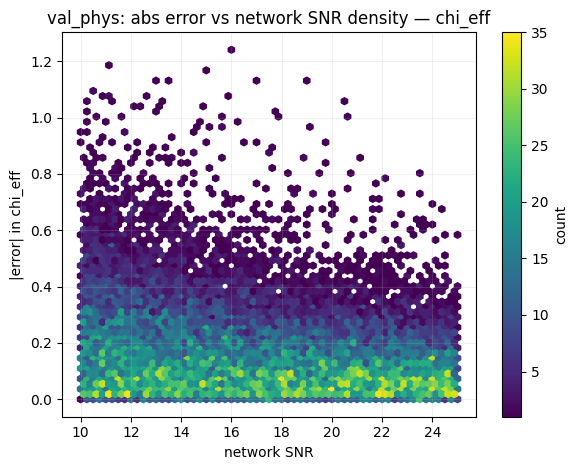

In [12]:
plot_abs_error_vs_quantity_density(
    quantity=snr_val,
    y_true=y_val_phys,
    y_pred=pred_val_phys,
    label_names=label_names,
    quantity_name="network SNR",
    split_name="val_phys",
)

### Error vs parameters (mass, distance, ...)

In [13]:
with h5py.File(dataset_path, "r") as f:
    mass_1_all = f["parameters/mass_1"][:]
    mass_2_all = f["parameters/mass_2"][:]
    distance_all = f["parameters/distance"][:]

mass_1_val = mass_1_all[val_idx]
mass_2_val = mass_2_all[val_idx]
distance_val = distance_all[val_idx]

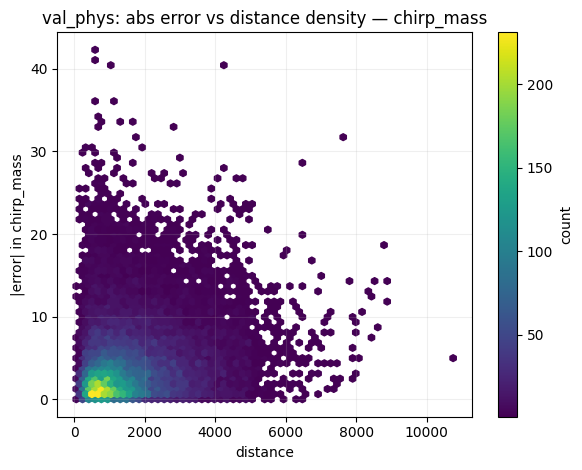

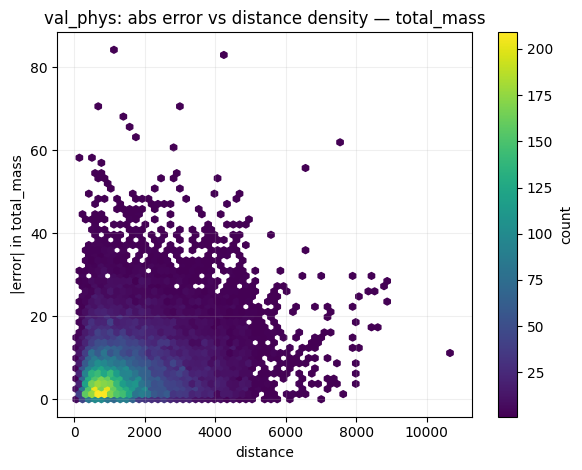

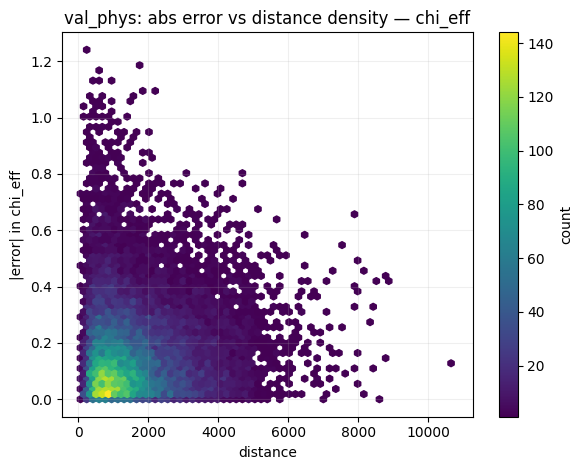

In [16]:
from src.models.plots import plot_abs_error_vs_quantity_density

plot_abs_error_vs_quantity_density(
    quantity=distance_val,
    y_true=y_val_phys,
    y_pred=pred_val_phys,
    label_names=label_names,
    quantity_name="distance",
    split_name="val_phys",
)

For all labels:

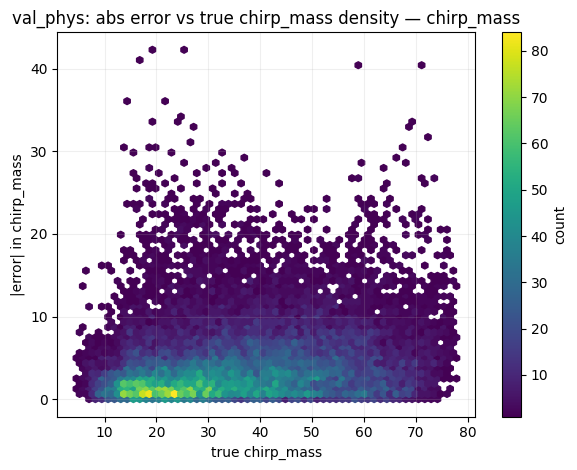

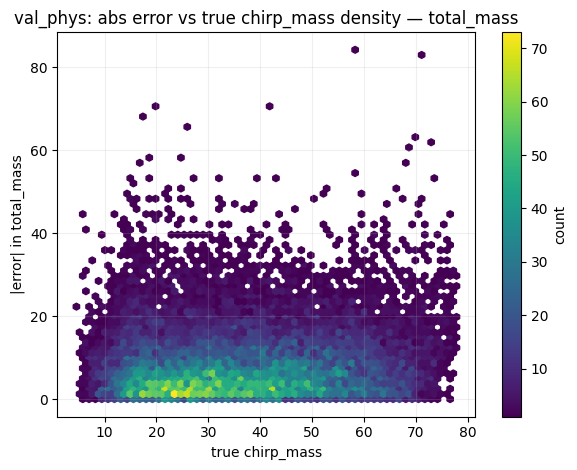

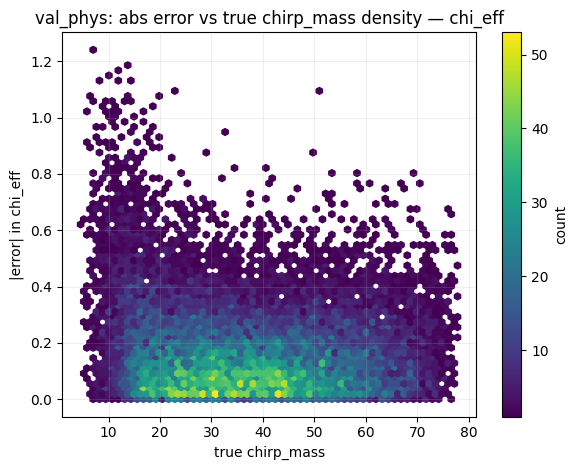

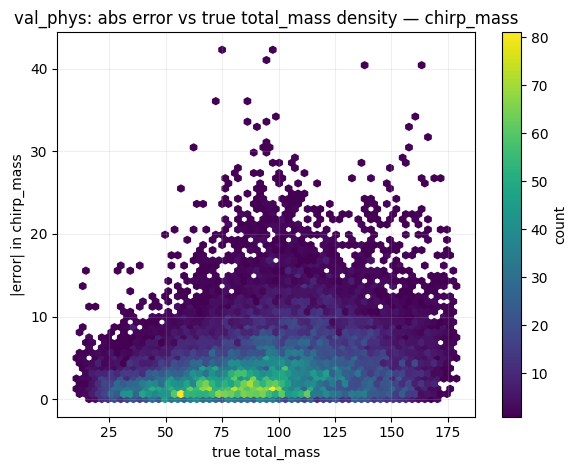

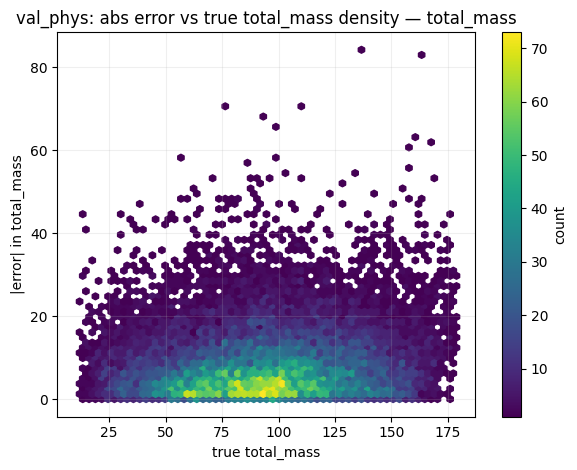

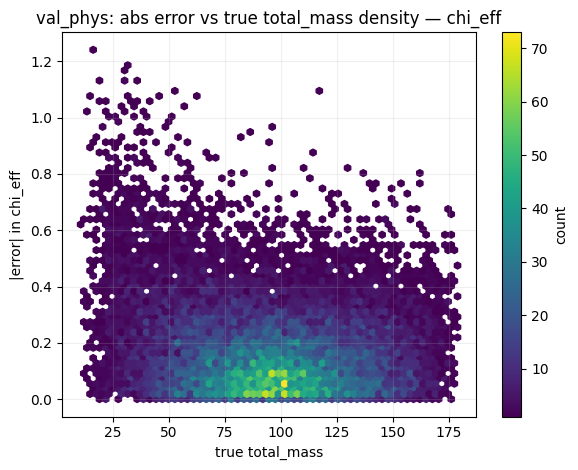

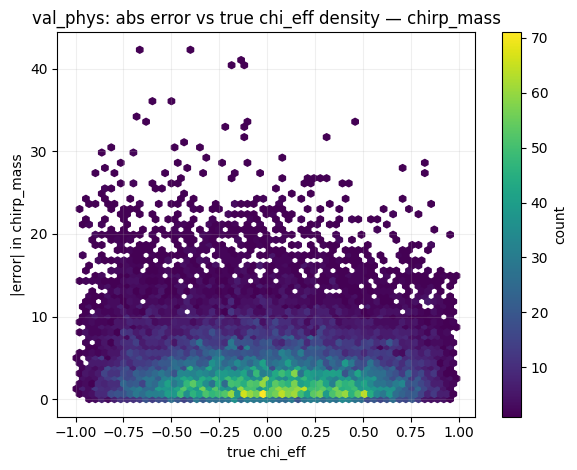

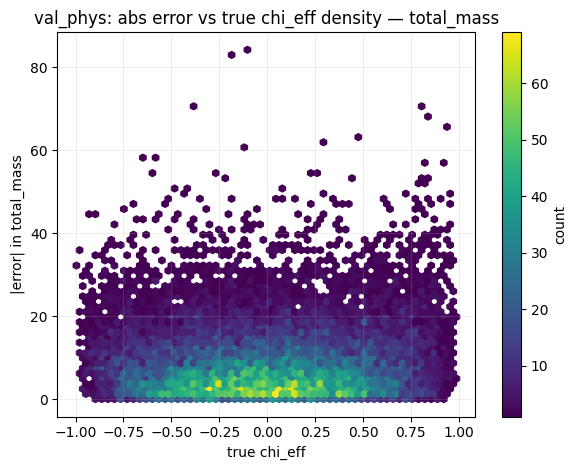

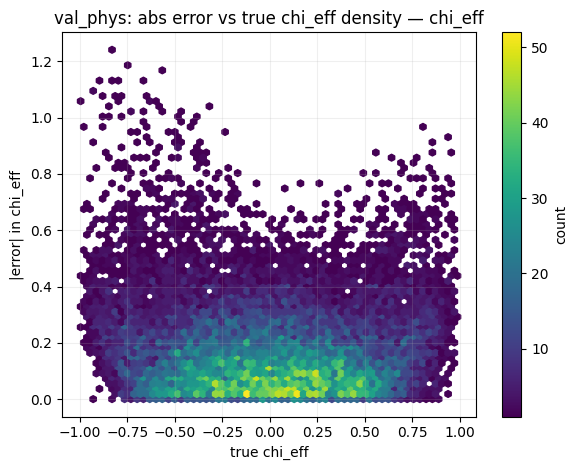

In [17]:
for j, label in enumerate(label_names):
    plot_abs_error_vs_quantity_density(
        quantity=y_val_phys[:, j],
        y_true=y_val_phys,
        y_pred=pred_val_phys,
        label_names=label_names,
        quantity_name=f"true {label}",
        split_name="val_phys",
    )

### Binned error

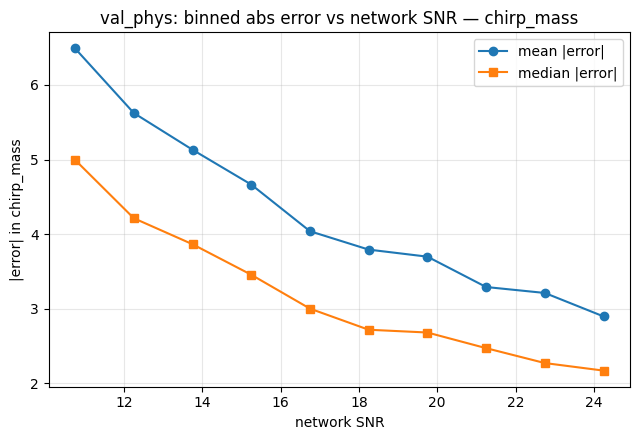


chirp_mass — counts per bin:
[2536 2414 2255 2061 1936 1882 1772 1791 1729 1624]


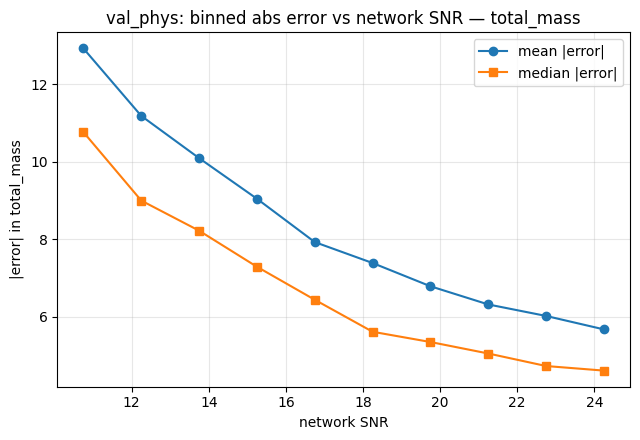


total_mass — counts per bin:
[2536 2414 2255 2061 1936 1882 1772 1791 1729 1624]


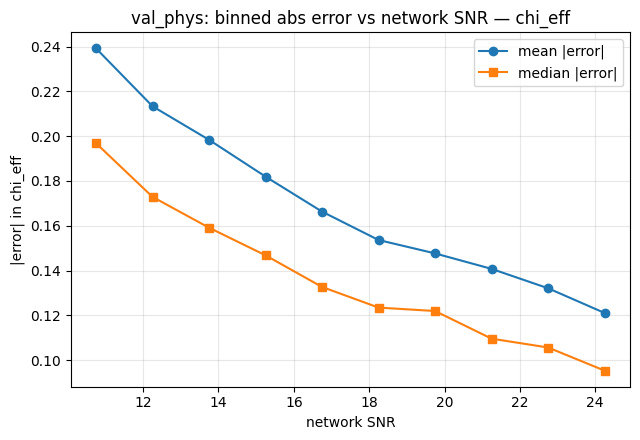


chi_eff — counts per bin:
[2536 2414 2255 2061 1936 1882 1772 1791 1729 1624]


In [24]:
plot_binned_error_vs_quantity(
    quantity=snr_val,
    y_true=y_val_phys,
    y_pred=pred_val_phys,
    label_names=label_names,
    quantity_name="network SNR",
    split_name="val_phys",
    n_bins=10,
)

USEFUL PLOTS 
_________________________

1. pred vs true density
2. residual vs true density
3. binned abs error vs SNR
4. binned abs error vs true chirp_mass / total_mass / chi_eff

## Save the metrics (cvs)

In [19]:
eval_dir = RESULTS_DIR / "evaluation"
eval_dir.mkdir(parents=True, exist_ok=True)

metrics_std_path = eval_dir / f"{checkpoint_id}_metrics_std.csv"
metrics_phys_path = eval_dir / f"{checkpoint_id}_metrics_phys.csv"

metrics_all_std.to_csv(metrics_std_path, index=False)
metrics_all_phys.to_csv(metrics_phys_path, index=False)

print("Saved:", metrics_std_path)
print("Saved:", metrics_phys_path)

Saved: /scratch/vserrano/cbc_pe_data/results/evaluation/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_simple_emb64_mse_MSELoss_seed123_metrics_std.csv
Saved: /scratch/vserrano/cbc_pe_data/results/evaluation/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_simple_emb64_mse_MSELoss_seed123_metrics_phys.csv


## Comparing models

In [20]:
prediction_files = sorted(RESULTS_DIR.glob("*train_val_predictions_embeddings.npz"))

for p in prediction_files:
    print(p.name)

bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_simple_emb64_mse_MSELoss_seed123_train_val_predictions_embeddings.npz


In [21]:
from src.models.utils import summarize_prediction_file

summary_rows = [summarize_prediction_file(p) for p in prediction_files]

summary_df = pd.DataFrame(summary_rows).sort_values("val_MSE_global")
summary_df


,file,val_MSE_global,val_MAE_global,chirp_mass_MSE,chirp_mass_MAE,chirp_mass_R2,total_mass_MSE,total_mass_MAE,total_mass_R2,chi_eff_MSE,chi_eff_MAE,chi_eff_R2
0,bbh_processed_4s_seobnrv4opt_snr10-25_n100_000...,0.177083,0.305378,0.140808,0.268875,0.8573,0.112468,0.249743,0.885663,0.277973,0.397517,0.725214
